# 校準式空間 GEV 模擬：完整驗證流程

本 notebook 集中執行：

$$
\text{已知空間真值}
\rightarrow
\text{540 monthly maxima}
\rightarrow
\text{Frozen NN}
\rightarrow
\text{nested buffered Spatial CV}
\rightarrow
\text{FFS + kernel selection}
\rightarrow
\text{OOF parameter recovery}
\rightarrow
RL_{50},RL_{100}.
$$

模型選擇階段只可使用 NN 估計值與候選 predictors；模擬真值只能在 OOF 預測完成後用於評分。

## 0. 執行設定

第一次只想檢查資料時，執行 generation 與 diagnostics 即可。完整 nested Spatial CV 很耗時，確認前段輸出合理後再開啟。

In [2]:
from pathlib import Path
import sys
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT if (CURRENT / "src").exists() else CURRENT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

SIM_DIR = PROJECT_ROOT / "data" / "simulated" / "calibrated_final_model"
CV_DIR = SIM_DIR / "nested_spatial_cv_monthly"
TIME_PATH = SIM_DIR / "simulation_time.csv"
FIGURE_DIR = Path.home() / "Desktop" / "picture"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

RUN_COMPLETE_100_REPLICATES = False  # 確認後改成 True，正式流程可中斷續跑
RUN_GENERATION = False                # 單次 pilot 資料生成
RUN_DIAGNOSTICS = True
RUN_NESTED_SPATIAL_CV = False         # 單次 pilot nested CV
N_REPLICATES = 100
PILOT_REPLICATES = 1
N_YEARS = 45
MONTHS_PER_YEAR = 12
OUTER_FOLDS = 5
INNER_FOLDS = 4
MAX_TRAIN = 800
MIN_TRAIN = 100
MAX_FFS_STEPS = 3
N_JOBS = -2
DISPLAY_CV_DIR = (
    CV_DIR / "replicate_000"
    if RUN_COMPLETE_100_REPLICATES
    else CV_DIR
)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SIM_DIR =", SIM_DIR)
print("Formal replicates =", N_REPLICATES)

PROJECT_ROOT = C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN
SIM_DIR = C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\simulated\calibrated_final_model
Formal replicates = 100


## 正式研究：100 次完整模擬

每個 replicate 都重新生成空間真值與 540 個月最大值，接著執行 Frozen NN、nested buffered Spatial CV、FFS、kernel selection，以及 OOF 參數與 return-level 評估。

100 次依序執行；單一 replicate 內的候選模型使用 `N_JOBS=-2` 平行運算。每次完成後立即寫入 `simulation_time.csv`，重新啟動時會略過已有完整輸出與計時紀錄的 replicate。

In [3]:
from calibrated_parametric_simulation import CalibratedSimulationConfig
from calibrated_simulation_study import (
    CompleteSimulationStudyConfig,
    run_complete_simulation_study,
)

if RUN_COMPLETE_100_REPLICATES:
    generation_config = CalibratedSimulationConfig(
        n_years=N_YEARS,
        months_per_year=MONTHS_PER_YEAR,
        n_replicates=N_REPLICATES,
        calibration_max_train=MAX_TRAIN,
        n_restarts_optimizer=0,
        seed=20260820,
    )
    study_config = CompleteSimulationStudyConfig(
        n_replicates=N_REPLICATES,
        outer_folds=OUTER_FOLDS,
        inner_folds=INNER_FOLDS,
        max_train=MAX_TRAIN,
        min_train=MIN_TRAIN,
        max_ffs_steps=MAX_FFS_STEPS,
        n_jobs=N_JOBS,
        save_monthly_maxima=True,
        resume=True,
    )
    study_outputs = run_complete_simulation_study(
        study_config=study_config,
        simulation_config=generation_config,
        output_directory=SIM_DIR,
        cv_root=CV_DIR,
        time_path=TIME_PATH,
    )
else:
    print("尚未啟動正式 100 次；確認設定後將 RUN_COMPLETE_100_REPLICATES 改為 True。")

尚未啟動正式 100 次；確認設定後將 RUN_COMPLETE_100_REPLICATES 改為 True。


## RMSE、MAE 與 Bias 的意義

令第 $i$ 個 GRID 的 OOF 誤差為：

$$
e_i=\widehat{y}_i^{\mathrm{OOF}}-y_i^{\mathrm{true}}.
$$

- **RMSE**：$\sqrt{n^{-1}\sum_i e_i^2}$。對大誤差懲罰較重，作為主要準確度指標，越小越好。
- **MAE**：$n^{-1}\sum_i |e_i|$。代表一般 GRID 的平均絕對誤差，越小越好。
- **Bias**：$n^{-1}\sum_i e_i$。正值表示整體高估，負值表示整體低估，越接近 0 越好。

100 次完成後，不只報告單一數值，而是報告各指標跨 replicate 的平均、標準差、中位數與 2.5%--97.5% 模擬區間。

In [4]:
METRIC_SUMMARY_PATH = SIM_DIR / "simulation_metric_summary.csv"
if TIME_PATH.exists():
    simulation_time = pd.read_csv(TIME_PATH)
    display(simulation_time.tail(10))
    completed_time = simulation_time.loc[simulation_time["status"].eq("completed")]
    if not completed_time.empty:
        last = completed_time.iloc[-1]
        display(pd.DataFrame({
            "completed_replicates": [len(completed_time)],
            "average_time": [last["running_average_hms"]],
            "total_time": [last["cumulative_hms"]],
        }))
else:
    print("尚未產生 simulation_time.csv。")

if METRIC_SUMMARY_PATH.exists():
    metric_summary = pd.read_csv(METRIC_SUMMARY_PATH)
    display(metric_summary)
else:
    print("尚未產生 100 次誤差彙整。")

,replicate,replicate_label,status,started_at_utc,finished_at_utc,elapsed_seconds,elapsed_hms,running_average_seconds,running_average_hms,cumulative_seconds,cumulative_hms
90,90,replicate_090,completed,2026-09-03T04:30:40.675722+00:00,2026-09-03T04:42:09.081292+00:00,688.405557,00:11:28,662.625124,00:11:03,60298.886319,16:44:59
91,91,replicate_091,completed,2026-09-03T04:42:09.435822+00:00,2026-09-03T04:54:10.453475+00:00,721.017640,00:12:01,663.259826,00:11:03,61019.903959,16:57:00
92,92,replicate_092,completed,2026-09-03T04:54:10.797007+00:00,2026-09-03T05:04:29.612250+00:00,618.815229,00:10:19,662.781927,00:11:03,61638.719188,17:07:19
93,93,replicate_093,completed,2026-09-03T05:04:30.106413+00:00,2026-09-03T05:14:42.578214+00:00,612.471787,00:10:12,662.246712,00:11:02,62251.190975,17:17:31
94,94,replicate_094,completed,2026-09-03T05:14:43.095275+00:00,2026-09-03T05:27:32.978656+00:00,770.898226,00:12:51,663.390413,00:11:03,63022.089201,17:30:22
95,95,replicate_095,completed,2026-09-03T05:27:33.328901+00:00,2026-09-03T05:40:48.948482+00:00,795.618747,00:13:16,664.767791,00:11:05,63817.707948,17:43:38
96,96,replicate_096,completed,2026-09-03T06:00:34.302595+00:00,2026-09-03T06:12:48.537215+00:00,734.234603,00:12:14,665.483944,00:11:05,64551.942551,17:55:52
97,97,replicate_097,completed,2026-09-03T06:12:48.890032+00:00,2026-09-03T06:23:03.571901+00:00,614.681855,00:10:15,664.965555,00:11:05,65166.624406,18:06:07
98,98,replicate_098,completed,2026-09-03T06:23:03.922806+00:00,2026-09-03T06:34:07.175829+00:00,663.253011,00:11:03,664.948257,00:11:05,65829.877417,18:17:10
99,99,replicate_099,completed,2026-09-03T06:34:07.519314+00:00,2026-09-03T06:44:41.776181+00:00,634.256854,00:10:34,664.641343,00:11:05,66464.134271,18:27:44


,completed_replicates,average_time,total_time
0,100,00:11:05,18:27:44


,result_type,outcome,estimator,metric,n_replicates,mean,sd,median,q025,q975,minimum,maximum
0,parameter,mu,Frozen NN,RMSE,100,0.038447,0.001794,0.038424,0.035546,0.042047,0.034440,0.043458
1,parameter,mu,Frozen NN,MAE,100,0.029995,0.001399,0.030076,0.027837,0.033054,0.027117,0.034264
2,parameter,mu,Frozen NN,Bias,100,-0.001526,0.001311,-0.001545,-0.004004,0.000877,-0.004685,0.001034
3,parameter,mu,Nested OOF GP,RMSE,100,0.632845,0.063423,0.629896,0.530311,0.791473,0.510691,0.814382
4,parameter,mu,Nested OOF GP,MAE,100,0.506337,0.052902,0.499672,0.419713,0.635875,0.405953,0.667828
5,parameter,mu,Nested OOF GP,Bias,100,-0.048008,0.074629,-0.049447,-0.207156,0.092306,-0.250220,0.175803
6,parameter,log_sigma,Frozen NN,RMSE,100,0.057455,0.002249,0.057569,0.052904,0.061178,0.051112,0.061519
7,parameter,log_sigma,Frozen NN,MAE,100,0.043346,0.001481,0.043315,0.040159,0.046058,0.038772,0.046575
8,parameter,log_sigma,Frozen NN,Bias,100,-0.016852,0.002280,-0.016792,-0.021054,-0.012486,-0.022791,-0.010483
9,parameter,log_sigma,Nested OOF GP,RMSE,100,0.205558,0.022237,0.202292,0.171663,0.261721,0.169239,0.274008


## 1. 依真實最終模型生成已知真值

生成式使用真實臺灣本島 GRID、真實候選 predictors，以及真實資料最終選定的 mean structure 與 GP kernel。每個 replicate 重新抽出空間隨機效應與 45 年共 540 個月最大值。

In [5]:
from calibrated_parametric_simulation import (
    CalibratedSimulationConfig,
    run_calibrated_simulation,
)

if RUN_GENERATION:
    simulation_config = CalibratedSimulationConfig(
        n_years=N_YEARS,
        n_replicates=PILOT_REPLICATES,
        months_per_year=MONTHS_PER_YEAR,
        calibration_max_train=MAX_TRAIN,
        n_restarts_optimizer=0,
        seed=20260820,
    )
    generated_paths = run_calibrated_simulation(
        config=simulation_config,
        output_directory=SIM_DIR,
    )
    display(pd.DataFrame({"generated_file": [str(path) for path in generated_paths]}))
else:
    print("略過重新生成；使用 SIM_DIR 中既有 replicate。")

略過重新生成；使用 SIM_DIR 中既有 replicate。


## 2. 確認 monthly maxima、已知參數與 Frozen NN 輸出

每個 GRID 應有 45 年乘 12 月，共 540 個 monthly maxima。

In [6]:
MODEL_READY_PATH = SIM_DIR / "replicate_000_model_ready.csv"
MONTHLY_PATH = SIM_DIR / "replicate_000_monthly_maxima.csv"
NN_METRIC_PATH = SIM_DIR / "replicate_000_nn_recovery_metrics.csv"

model_ready = pd.read_csv(MODEL_READY_PATH)
monthly_maxima = pd.read_csv(MONTHLY_PATH)
nn_metrics = pd.read_csv(NN_METRIC_PATH)

summary = pd.DataFrame({
    "item": ["GRID count", "monthly maxima columns", "xi clipped GRID"],
    "value": [
        len(model_ready),
        sum(column.startswith("monthly_max_") for column in monthly_maxima.columns),
        int(model_ready["xi_clipped"].sum()),
    ],
})
display(summary)
display(nn_metrics)

,item,value
0,GRID count,1385
1,monthly maxima columns,540
2,xi clipped GRID,4


,outcome,RMSE,MAE,Bias,correlation
0,mu,0.036046,0.028306,-0.002177,0.999960
1,log_sigma,0.053081,0.040233,-0.014176,0.968197
2,xi,0.032389,0.025517,0.003350,0.965848
3,RL50,0.376564,0.204135,-0.022512,0.994523
4,RL100,0.462956,0.242430,-0.019353,0.991712


## 3. 模擬生成的臺灣月最大溫資料

這裡展示的是由已知空間 GEV 參數實際抽出的 monthly maxima，不是參數曲面。三個月份使用共同色階，以比較空間位置與月份間的隨機變動。


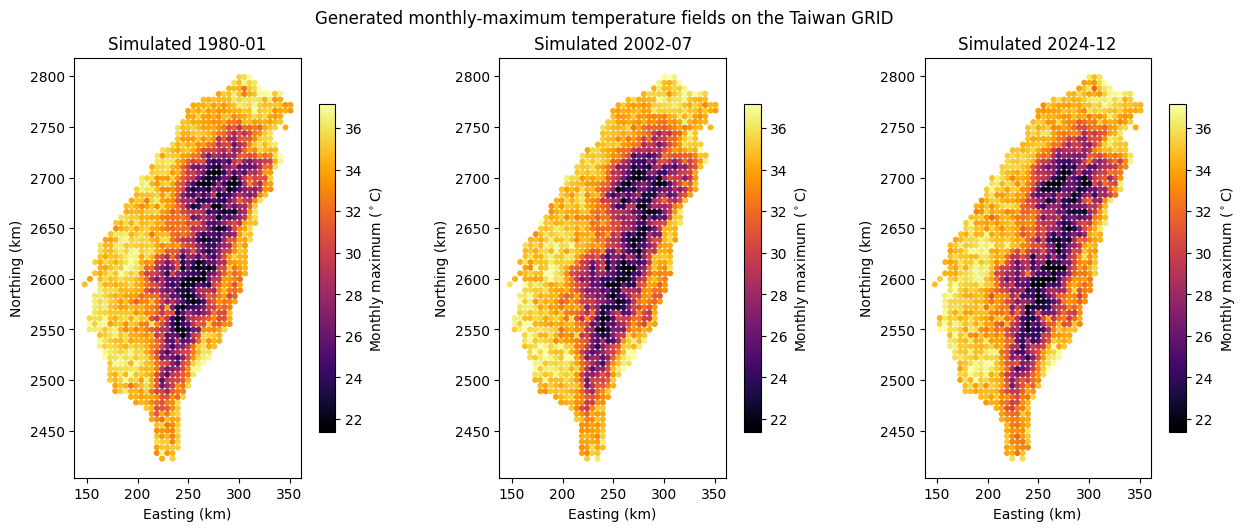

Saved: C:\Users\User.DESKTOP-4RV84M1\Desktop\picture\calibrated_simulation_monthly_maxima_examples.png


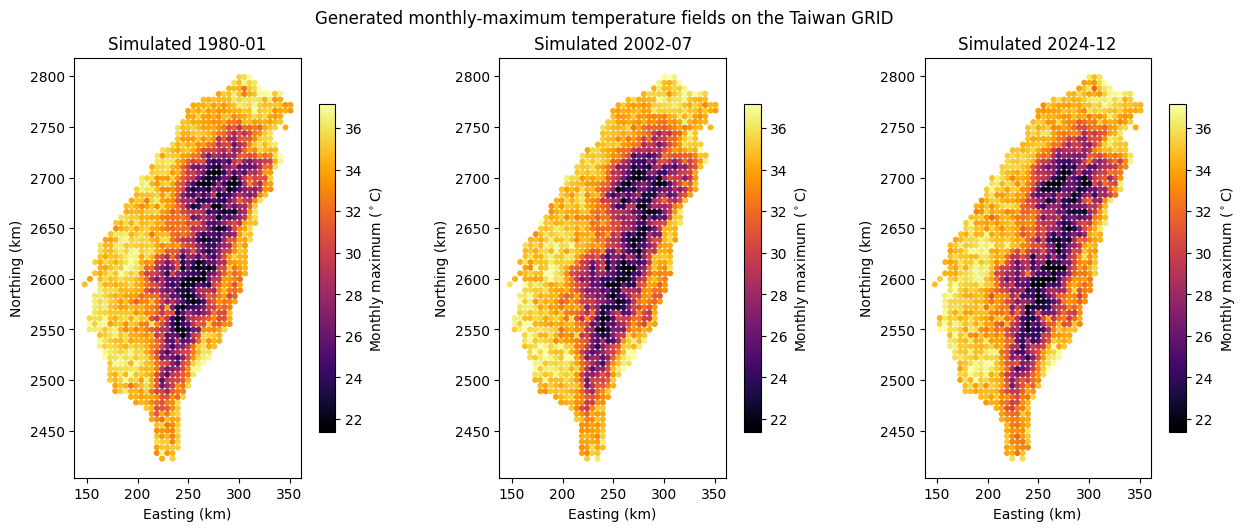

In [7]:
from calibrated_simulation_diagnostics import plot_monthly_maxima_examples

monthly_temperature_figure = plot_monthly_maxima_examples(
    model_ready,
    monthly_maxima,
    year_months=((1980, 1), (2002, 7), (2024, 12)),
)
monthly_temperature_path = FIGURE_DIR / "calibrated_simulation_monthly_maxima_examples.png"
monthly_temperature_figure.savefig(
    monthly_temperature_path,
    dpi=220,
    bbox_inches="tight",
)

display(monthly_temperature_figure)
print("Saved:", monthly_temperature_path)


## 4. 檢查模擬曲面是否過度平滑或過度粗糙

比較真實 NN 曲面與模擬真值的共同色階、分布、標準化 variogram 與最近鄰粗糙度。

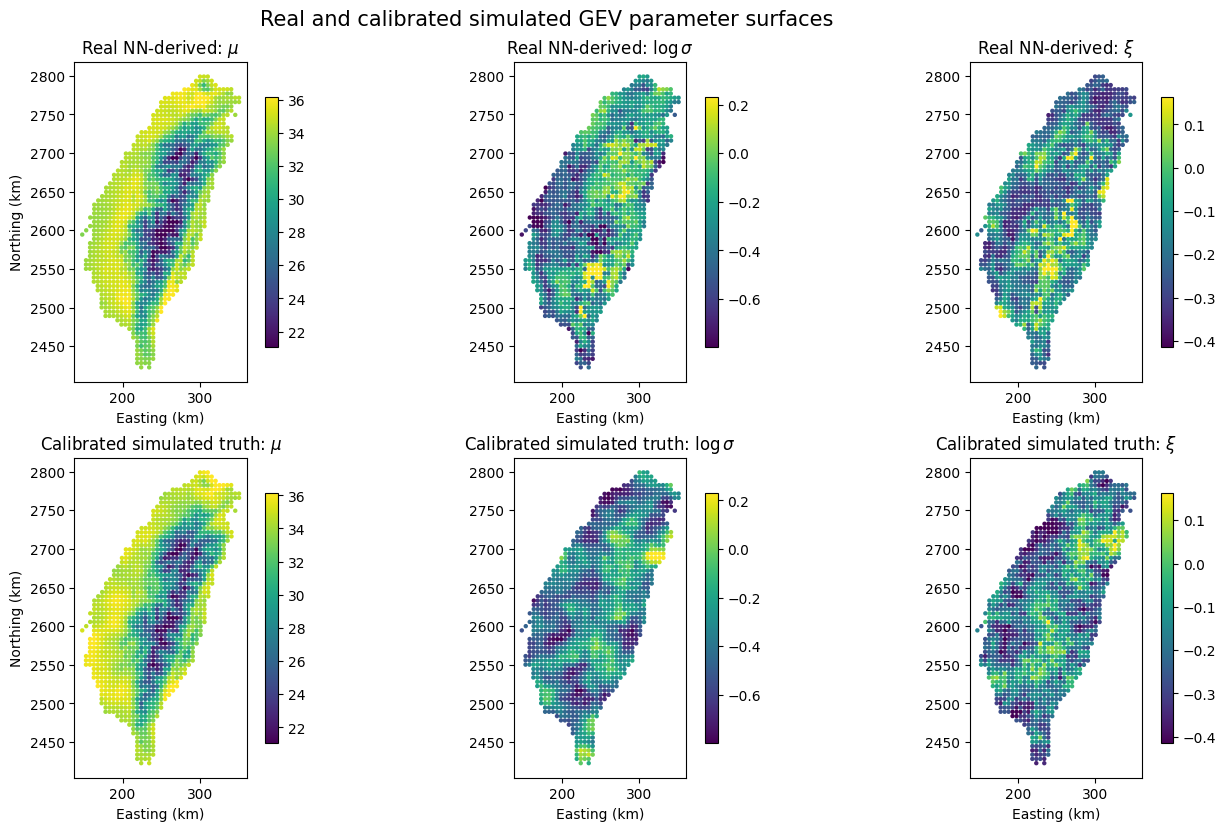

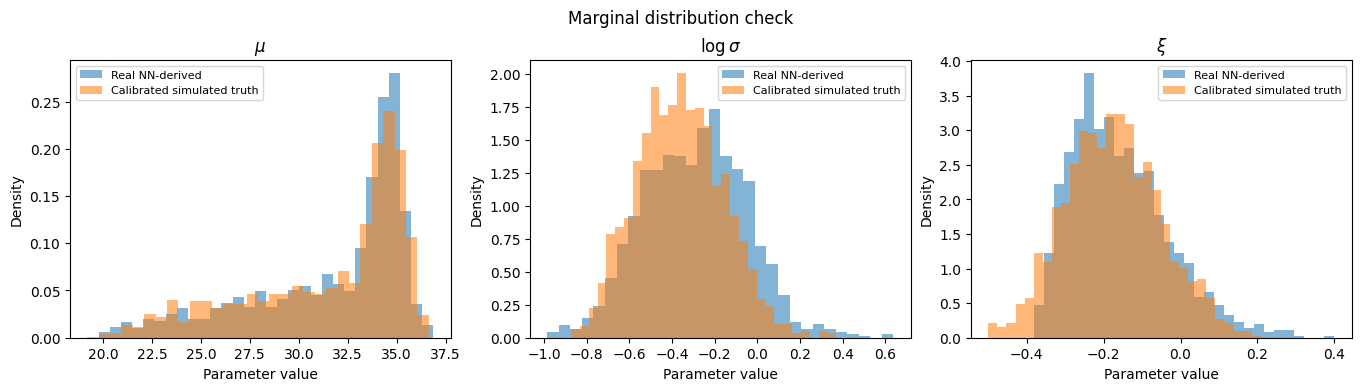

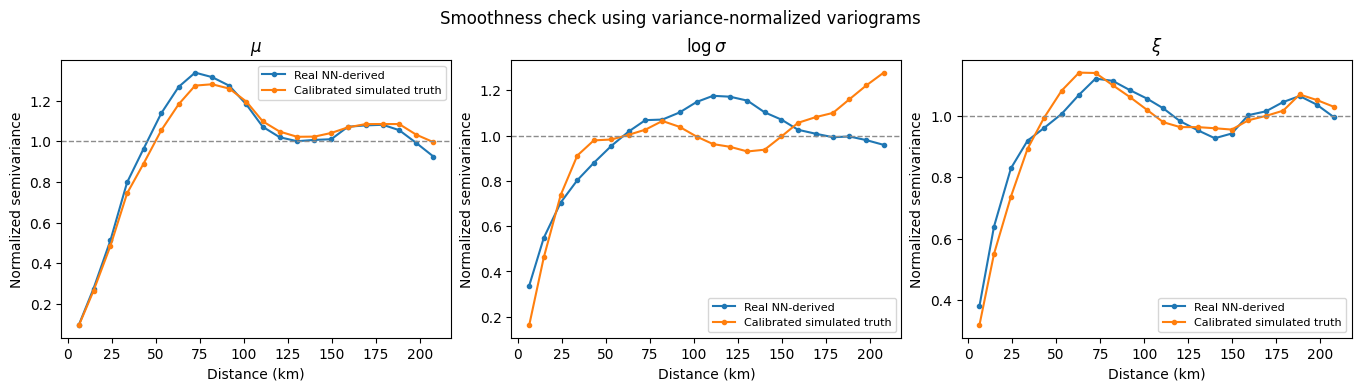

,parameter,real_surface_sd,real_nn_rms_difference,real_normalized_roughness,simulated_surface_sd,simulated_nn_rms_difference,simulated_normalized_roughness,roughness_ratio_simulated_to_real
0,mu,3.953219,1.669104,0.422214,4.022125,1.662934,0.413447,0.979235
1,log_sigma,0.239585,0.190285,0.794227,0.201132,0.094661,0.470640,0.592576
2,xi,0.126265,0.106338,0.842185,0.123461,0.090585,0.733719,0.871208


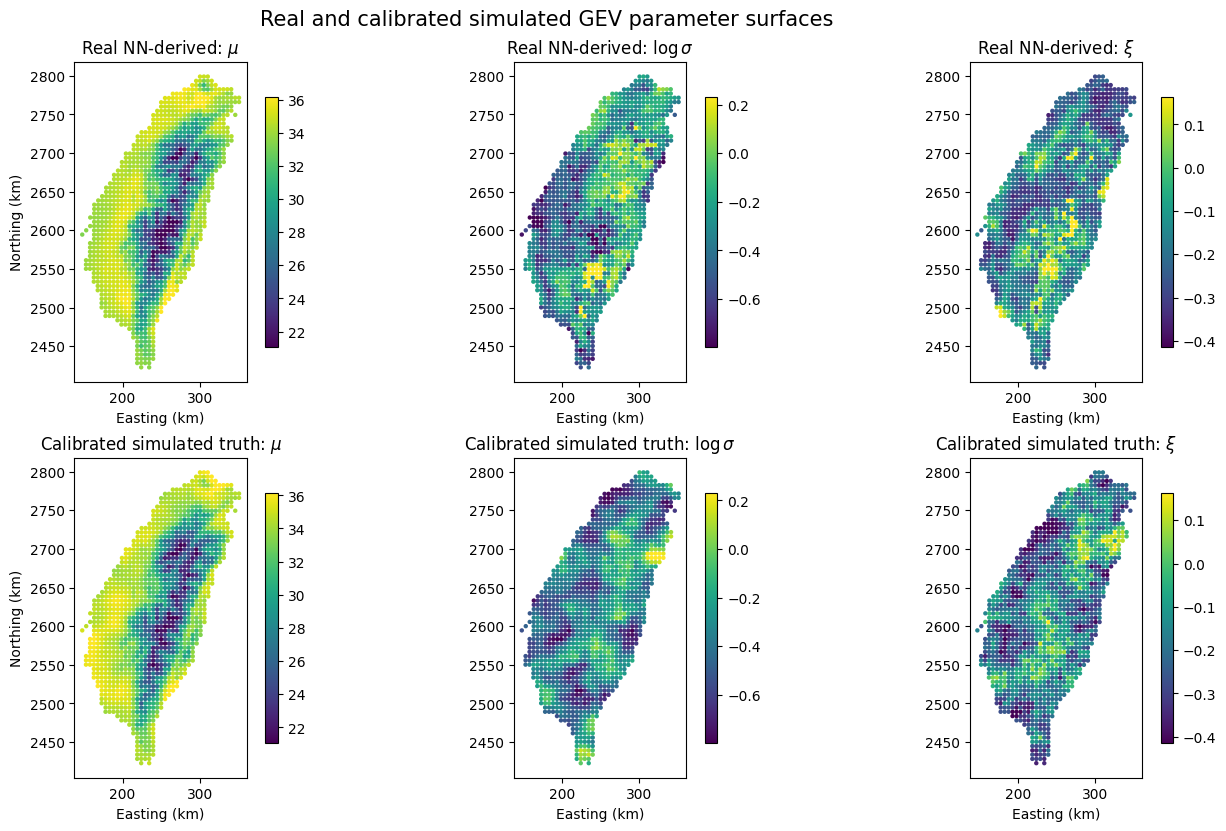

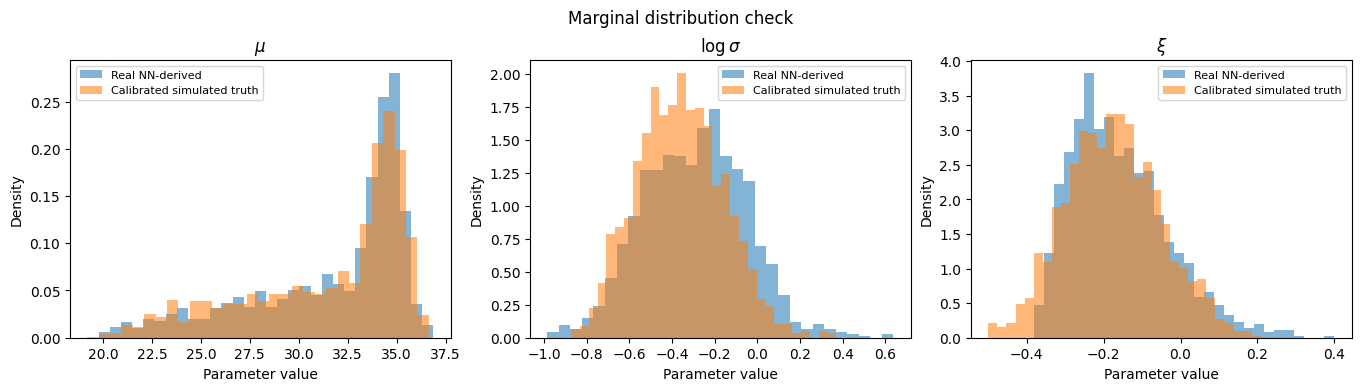

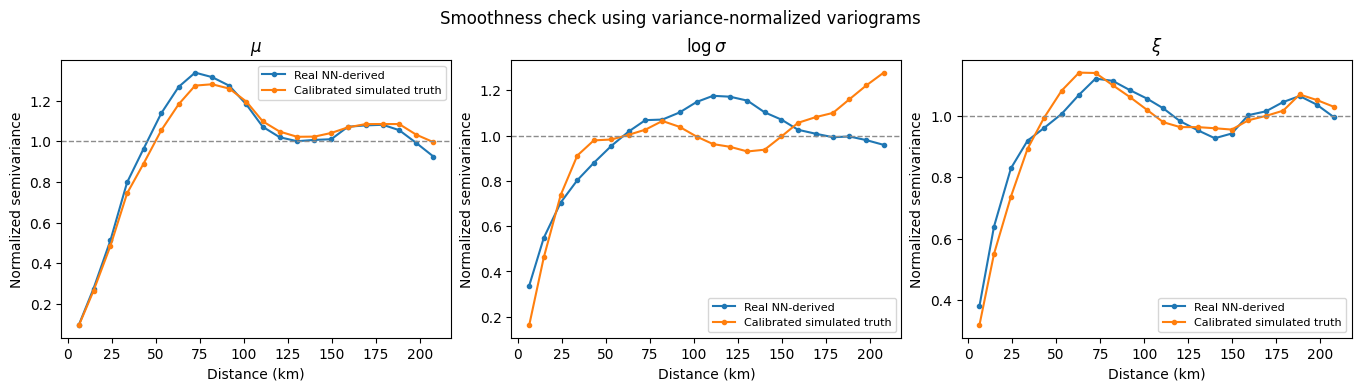

In [8]:
from calibrated_simulation_diagnostics import run_diagnostics

if RUN_DIAGNOSTICS:
    diagnostics = run_diagnostics(
        simulation_path=MODEL_READY_PATH,
        figure_directory=FIGURE_DIR,
        table_directory=TABLE_DIR,
    )
    for name in ("surfaces", "distributions", "variograms"):
        display(diagnostics["figures"][name])
    display(diagnostics["roughness"])
else:
    print("略過 diagnostics。")

## 5. 建立 outer geographic folds

Outer folds 只負責最後評估。Outer test fold 與 buffer 內資料不會進入 inner FFS 或 kernel selection。

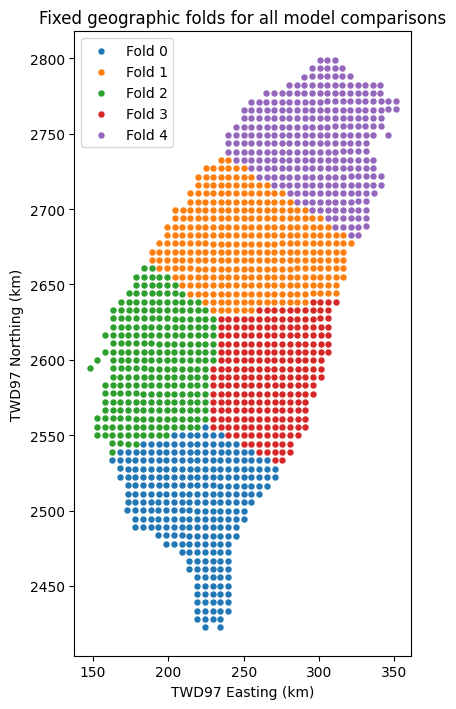

,spatial_fold,n_test_grid
0,0,271
1,1,324
2,2,259
3,3,237
4,4,294


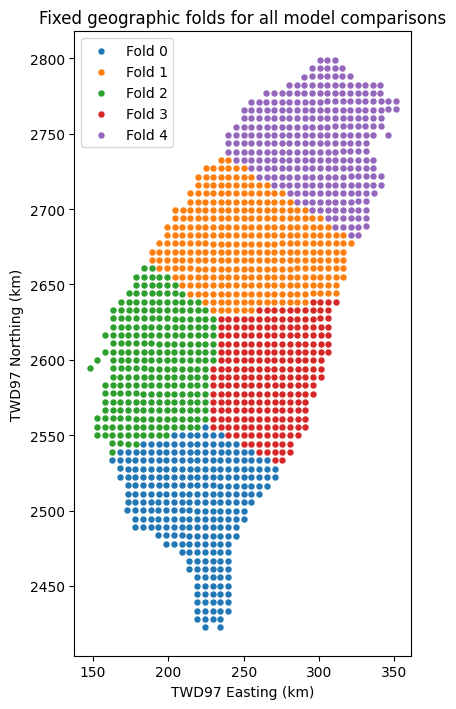

In [9]:
from elevation_gp_analysis import prepare_spatial_folds

outer_preview, fold_figure = prepare_spatial_folds(
    model_ready,
    n_folds=OUTER_FOLDS,
    random_state=20260721,
)
fold_figure.savefig(FIGURE_DIR / "calibrated_simulation_outer_folds.png", dpi=220, bbox_inches="tight")
display(fold_figure)
display(
    outer_preview.groupby("spatial_fold")
    .size()
    .rename("n_test_grid")
    .reset_index()
)

## 6. Nested buffered Spatial CV、FFS 與 kernel selection

對每個 outer fold：

1. 保留一區作 outer test。
2. 刪除 test 周圍 target-specific buffer 內的 training GRID。
3. 僅在 outer training 內建立 inner folds。
4. Inner buffered CV 同時執行 grouped FFS 與 RBF/Matérn kernel selection。
5. 用選定模型預測完全未參與選模的 outer test。
6. 五區合併為 OOF predictions。

這一格最耗時。

In [10]:
from calibrated_simulation_spatial_cv import run_evaluation

if RUN_NESTED_SPATIAL_CV:
    cv_outputs = run_evaluation(
        input_path=MODEL_READY_PATH,
        output_directory=DISPLAY_CV_DIR,
        outer_folds=OUTER_FOLDS,
        inner_folds=INNER_FOLDS,
        max_train=MAX_TRAIN,
        min_train=MIN_TRAIN,
        max_steps=MAX_FFS_STEPS,
        min_relative_improvement=0.01,
        maximum_allowed_vif=5.0,
        n_restarts=0,
        n_jobs=N_JOBS,
        random_state=20260721,
    )
else:
    print("尚未重跑 nested Spatial CV；若已有輸出，下一格會直接載入。")

尚未重跑 nested Spatial CV；若已有輸出，下一格會直接載入。


## 7. 載入 nested Spatial CV 結果

In [11]:
output_files = {
    "predictions": DISPLAY_CV_DIR / "calibrated_nested_predictions.csv",
    "selections": DISPLAY_CV_DIR / "calibrated_nested_selections.csv",
    "parameter_metrics": DISPLAY_CV_DIR / "calibrated_nested_parameter_metrics.csv",
    "return_level_predictions": DISPLAY_CV_DIR / "calibrated_nested_return_level_predictions.csv",
    "return_level_metrics": DISPLAY_CV_DIR / "calibrated_nested_return_level_metrics.csv",
    "metadata": DISPLAY_CV_DIR / "calibrated_nested_metadata.csv",
}

outputs_exist = all(path.exists() for path in output_files.values())
outputs_are_current = outputs_exist and all(
    path.stat().st_mtime >= MODEL_READY_PATH.stat().st_mtime
    for path in output_files.values()
)
if outputs_are_current:
    metadata_check = pd.read_csv(output_files["metadata"])
    current_hash = hashlib.sha256(MODEL_READY_PATH.read_bytes()).hexdigest()
    outputs_are_current = (
        str(metadata_check.loc[0, "input_sha256"]) == current_hash
        and str(metadata_check.loc[0, "block_scale"]).lower() == "monthly"
        and int(metadata_check.loc[0, "n_months"]) == 540
    )

if outputs_are_current:
    cv_outputs = {name: pd.read_csv(path) for name, path in output_files.items()}
    print("已載入既有 nested Spatial CV 輸出。")
else:
    missing = [str(path) for path in output_files.values() if not path.exists()]
    if outputs_exist:
        missing = ["既有 nested Spatial CV 輸出早於新的 monthly simulation，必須重跑。"]
    print("尚缺或輸出已過期；將 RUN_NESTED_SPATIAL_CV 改為 True 並執行第 6 節。")
    display(pd.DataFrame({"missing_file": missing}))

尚缺或輸出已過期；將 RUN_NESTED_SPATIAL_CV 改為 True 並執行第 6 節。


,missing_file
0,既有 nested Spatial CV 輸出早於新的 monthly simulation...


## 8. 模型選回結果

同一 predictor/kernel 若在多個 outer folds 被選回，表示選模較穩定。只看單一 replicate 不足以估計正式選回率。

In [12]:
if "cv_outputs" in globals() and "selections" in cv_outputs:
    selections = cv_outputs["selections"]
    display(selections)
    selection_frequency = (
        selections.groupby(
            ["target", "selected_groups", "predictors", "kernel", "nu"],
            dropna=False,
        )
        .size()
        .rename("outer_folds_selected")
        .reset_index()
        .sort_values(["target", "outer_folds_selected"], ascending=[True, False])
    )
    display(selection_frequency)

## 9. OOF 參數恢復

主要比較對象是已知模擬真值，不是 NN reference。

In [13]:
if "cv_outputs" in globals() and "parameter_metrics" in cv_outputs:
    display(cv_outputs["parameter_metrics"])

    predictions = cv_outputs["predictions"].merge(
        model_ready[["station", "x_km", "y_km"]],
        on="station",
        how="left",
        validate="many_to_one",
    )
    targets = [("mu", r"$\mu$"), ("log_sigma", r"$\log\sigma$"), ("xi", r"$\xi$")]
    columns = [
        ("true_value", "Truth"),
        ("nn_value", "Frozen NN"),
        ("oof_prediction", "Nested OOF GP"),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(12, 14), constrained_layout=True)
    for row, (target, label) in enumerate(targets):
        part = predictions.loc[predictions["target"].eq(target)]
        values = np.concatenate([part[column].to_numpy(float) for column, _ in columns])
        vmin, vmax = np.nanquantile(values, [0.01, 0.99])
        for col, (column, title) in enumerate(columns):
            points = axes[row, col].scatter(
                part["x_km"], part["y_km"], c=part[column],
                s=10, cmap="viridis", vmin=vmin, vmax=vmax,
            )
            axes[row, col].set_title(f"{label}: {title}")
            axes[row, col].set_aspect("equal")
            fig.colorbar(points, ax=axes[row, col], shrink=0.75)
    fig.savefig(FIGURE_DIR / "calibrated_simulation_oof_parameter_recovery.png", dpi=220, bbox_inches="tight")
    display(fig)

## 10. OOF return-level 恢復

$$
\widehat{RL}_{T}^{\mathrm{OOF}}
=
RL_T\!\left(
\widehat\mu^{\mathrm{OOF}},
\widehat{\log\sigma}^{\mathrm{OOF}},
\widehat\xi^{\mathrm{OOF}}
\right).
$$

比較 $widehat{RL}_{50}^{\mathrm{OOF}}$、$widehat{RL}_{100}^{\mathrm{OOF}}$ 與生成時已知真值。

In [14]:
if "cv_outputs" in globals() and "return_level_metrics" in cv_outputs:
    display(cv_outputs["return_level_metrics"])

    rl = cv_outputs["return_level_predictions"].merge(
        model_ready[["station", "x_km", "y_km"]],
        on="station",
        how="left",
        validate="many_to_one",
    )
    fig, axes = plt.subplots(2, 3, figsize=(12, 9), constrained_layout=True)
    columns = [
        ("true_return_level", "Truth"),
        ("nn_return_level", "Frozen NN"),
        ("oof_return_level", "Nested OOF GP"),
    ]
    for row, period in enumerate((50, 100)):
        part = rl.loc[rl["return_period"].eq(period)]
        values = np.concatenate([part[column].to_numpy(float) for column, _ in columns])
        vmin, vmax = np.nanquantile(values, [0.01, 0.99])
        for col, (column, title) in enumerate(columns):
            points = axes[row, col].scatter(
                part["x_km"], part["y_km"], c=part[column],
                s=10, cmap="magma", vmin=vmin, vmax=vmax,
            )
            axes[row, col].set_title(f"RL{period}: {title}")
            axes[row, col].set_aspect("equal")
            fig.colorbar(points, ax=axes[row, col], shrink=0.75)
    fig.savefig(FIGURE_DIR / "calibrated_simulation_oof_return_level_recovery.png", dpi=220, bbox_inches="tight")
    display(fig)

## 11. 結果判讀

完整流程需回答四件事：

- Frozen NN 能否恢復已知 GEV 參數。
- Inner FFS/kernel selection 能否穩定選回生成模型。
- Nested OOF GP 能否恢復未見區域的參數曲面。
- $RL_{50}$ 與 $RL_{100}$ 是否接近已知真值。

單一 replicate 只適合流程測試。正式研究使用 100 個獨立 replicates，報告 RMSE／MAE／Bias 分布、predictor 選回率、kernel 選回率，以及每次與總運算時間。

## 12. 100 次模擬的 RMSE 分布與真實資料比較

RMSE 的重複模擬分布**不應預期為 uniform（均勻分布）**。若流程穩定，RMSE 通常會集中在某個範圍，可能略為右偏；直方圖用來檢查離散程度、偏態與異常 replicate。

下圖使用每次完整流程的 Nested OOF GP RMSE。黑線為 100 次模擬平均，紅線為真實資料 OOF RMSE；表格同時報告標準差、變異係數與 95\% 經驗區間。所有數值只在顯示時四捨五入至小數點後兩位，計算與 CSV 保留原始精度。

> 比較限制：真實資料的參數真值未知，因此真實資料 RMSE 是相對於 NN estimates；模擬資料 RMSE 是相對於已知 simulated truth。兩者可作為校準診斷，但不能解讀成完全相同條件下的優劣檢定。

,Outcome,Real-data OOF RMSE,Simulation mean,Simulation SD,Simulation CV,Simulation median,Simulation 2.5%,Simulation 97.5%,Skewness
0,mu,0.77,0.63,0.06,0.10,0.63,0.53,0.79,0.67
1,log_sigma,0.24,0.21,0.02,0.11,0.20,0.17,0.26,0.90
2,xi,0.13,0.12,0.01,0.09,0.12,0.11,0.15,0.40
3,RL50,1.17,1.76,0.24,0.14,1.71,1.41,2.28,0.90
4,RL100,1.33,2.05,0.32,0.16,2.00,1.59,2.74,0.96


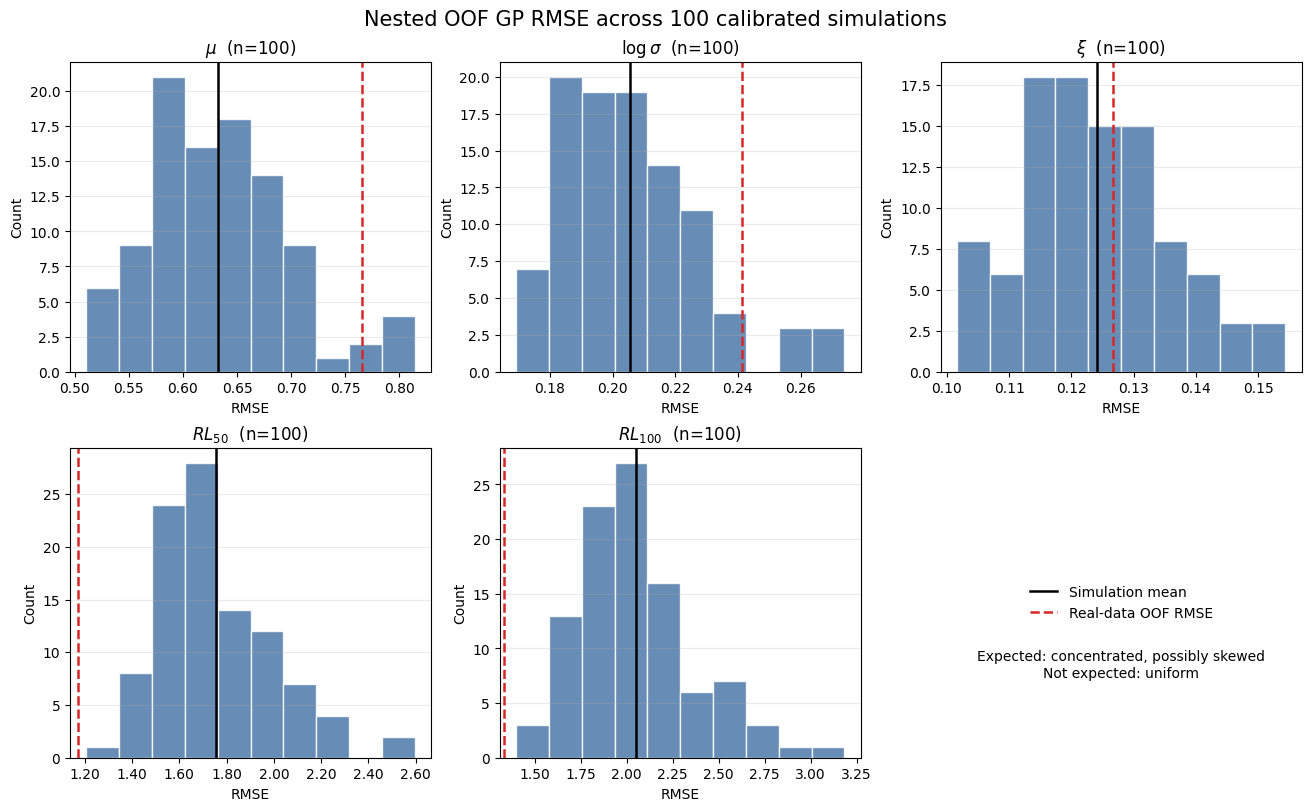

Saved table: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\tables\calibrated_simulation_real_vs_simulation_rmse.csv
Saved figure: C:\Users\User.DESKTOP-4RV84M1\Desktop\picture\calibrated_simulation_rmse_histograms.png


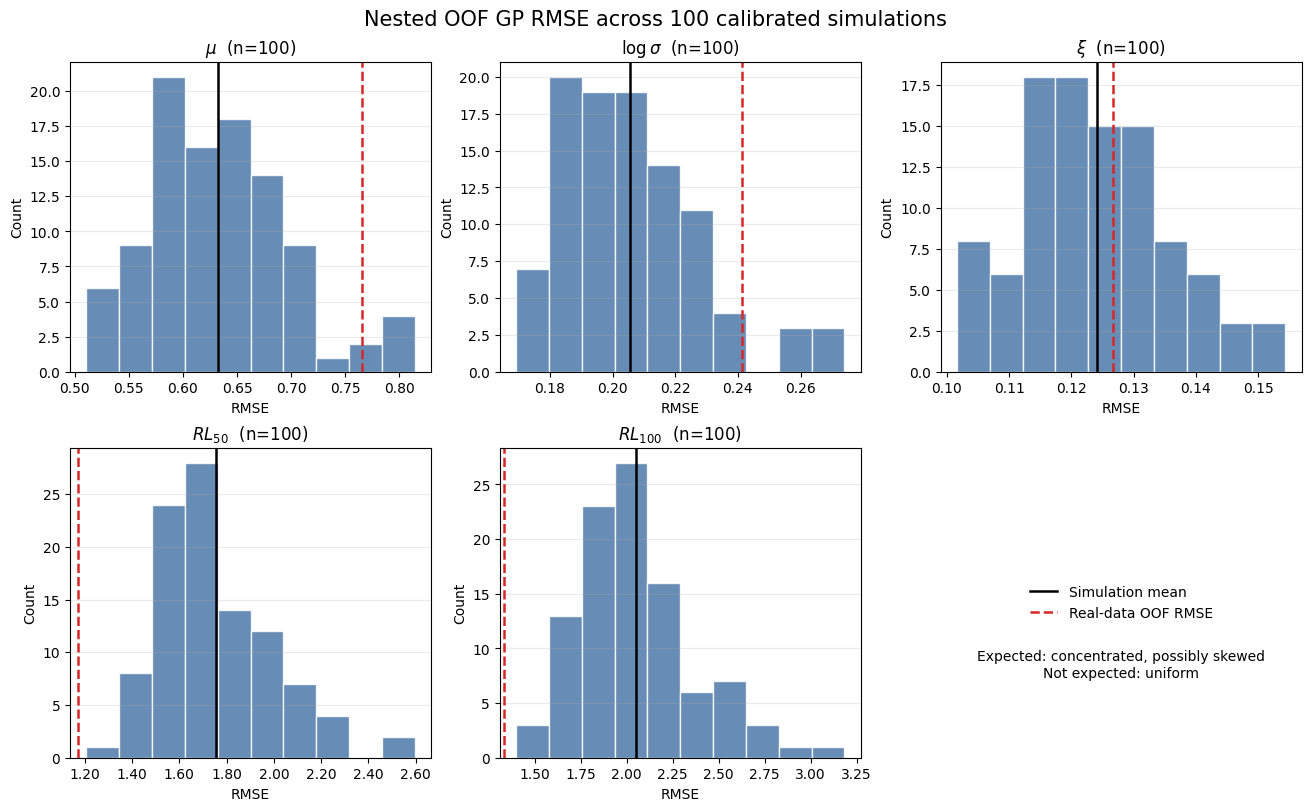

In [15]:
from matplotlib.ticker import FormatStrFormatter

SIMULATION_METRICS_PATH = SIM_DIR / "simulation_replicate_metrics.csv"
REAL_PARAMETER_METRICS_PATH = TABLE_DIR / "spatial_ffs_selected_models.csv"
REAL_RL_METRICS_PATH = TABLE_DIR / "spatial_ffs_selected_return_level_metrics.csv"
RMSE_COMPARISON_PATH = TABLE_DIR / "calibrated_simulation_real_vs_simulation_rmse.csv"
RMSE_FIGURE_PATH = FIGURE_DIR / "calibrated_simulation_rmse_histograms.png"

required_paths = [
    SIMULATION_METRICS_PATH,
    REAL_PARAMETER_METRICS_PATH,
    REAL_RL_METRICS_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"缺少 RMSE 輸入檔：{missing_paths}")

outcome_order = ["mu", "log_sigma", "xi", "RL50", "RL100"]
outcome_labels = {
    "mu": r"$\mu$",
    "log_sigma": r"$\log\sigma$",
    "xi": r"$\xi$",
    "RL50": r"$RL_{50}$",
    "RL100": r"$RL_{100}$",
}

simulation_metrics = pd.read_csv(SIMULATION_METRICS_PATH)
simulation_metrics["RMSE"] = pd.to_numeric(simulation_metrics["RMSE"], errors="raise")
sim_rmse = simulation_metrics.loc[
    simulation_metrics["estimator"].eq("Nested OOF GP")
    & simulation_metrics["outcome"].isin(outcome_order),
    ["replicate", "outcome", "RMSE"],
].copy()
if sim_rmse.duplicated(["replicate", "outcome"]).any():
    raise ValueError("同一 replicate/outcome 出現重複的 Nested OOF GP RMSE。")
replicate_counts = sim_rmse.groupby("outcome")["replicate"].nunique().reindex(outcome_order)
if replicate_counts.isna().any() or not replicate_counts.eq(N_REPLICATES).all():
    raise ValueError(
        f"Nested OOF GP RMSE 尚未完整：預期每個 outcome 有 {N_REPLICATES} 次，"
        f"目前為 {replicate_counts.to_dict()}"
    )

real_parameter_rmse = (
    pd.read_csv(REAL_PARAMETER_METRICS_PATH)[["target", "RMSE"]]
    .rename(columns={"target": "outcome", "RMSE": "real_data_oof_rmse"})
)
real_rl_rmse = pd.read_csv(REAL_RL_METRICS_PATH)
real_rl_rmse["outcome"] = "RL" + real_rl_rmse["return_period"].astype(int).astype(str)
real_rl_rmse = real_rl_rmse[["outcome", "RMSE_vs_NN_reference"]].rename(
    columns={"RMSE_vs_NN_reference": "real_data_oof_rmse"}
)
real_rmse = pd.concat([real_parameter_rmse, real_rl_rmse], ignore_index=True)
real_rmse["real_data_oof_rmse"] = pd.to_numeric(
    real_rmse["real_data_oof_rmse"], errors="raise"
)

simulation_summary = (
    sim_rmse.groupby("outcome")["RMSE"]
    .agg(
        n_replicates="size",
        simulation_mean="mean",
        simulation_sd="std",
        simulation_median="median",
        simulation_skewness="skew",
    )
)
simulation_summary["simulation_cv"] = (
    simulation_summary["simulation_sd"] / simulation_summary["simulation_mean"]
)
simulation_summary["simulation_q025"] = sim_rmse.groupby("outcome")["RMSE"].quantile(0.025)
simulation_summary["simulation_q975"] = sim_rmse.groupby("outcome")["RMSE"].quantile(0.975)

rmse_comparison = (
    real_rmse.merge(simulation_summary.reset_index(), on="outcome", how="inner", validate="one_to_one")
    .set_index("outcome")
    .reindex(outcome_order)
    .reset_index()
)
if rmse_comparison["real_data_oof_rmse"].isna().any() or len(rmse_comparison) != len(outcome_order):
    raise ValueError("真實資料與模擬資料的五個 RMSE outcome 無法完整配對。")
rmse_comparison.to_csv(RMSE_COMPARISON_PATH, index=False)

display_table = rmse_comparison[[
    "outcome",
    "real_data_oof_rmse",
    "simulation_mean",
    "simulation_sd",
    "simulation_cv",
    "simulation_median",
    "simulation_q025",
    "simulation_q975",
    "simulation_skewness",
]].rename(columns={
    "outcome": "Outcome",
    "real_data_oof_rmse": "Real-data OOF RMSE",
    "simulation_mean": "Simulation mean",
    "simulation_sd": "Simulation SD",
    "simulation_cv": "Simulation CV",
    "simulation_median": "Simulation median",
    "simulation_q025": "Simulation 2.5%",
    "simulation_q975": "Simulation 97.5%",
    "simulation_skewness": "Skewness",
})
display(display_table.style.format(precision=2))

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()
for ax, outcome in zip(axes, outcome_order):
    values = sim_rmse.loc[sim_rmse["outcome"].eq(outcome), "RMSE"].to_numpy(float)
    real_value = float(
        rmse_comparison.loc[rmse_comparison["outcome"].eq(outcome), "real_data_oof_rmse"].iloc[0]
    )
    ax.hist(values, bins=10, color="#4C78A8", edgecolor="white", alpha=0.85)
    ax.axvline(values.mean(), color="black", linewidth=1.8, label="Simulation mean")
    ax.axvline(real_value, color="#D62728", linestyle="--", linewidth=1.8, label="Real-data OOF RMSE")
    ax.set_title(f"{outcome_labels[outcome]}  (n={len(values)})")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Count")
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
axes[-1].axis("off")
axes[-1].legend(handles, labels, loc="center", frameon=False)
axes[-1].text(
    0.5, 0.30,
    "Expected: concentrated, possibly skewed\nNot expected: uniform",
    ha="center", va="center", transform=axes[-1].transAxes,
)
fig.suptitle("Nested OOF GP RMSE across 100 calibrated simulations", fontsize=15)
fig.savefig(RMSE_FIGURE_PATH, dpi=220, bbox_inches="tight")
display(fig)

print("Saved table:", RMSE_COMPARISON_PATH)
print("Saved figure:", RMSE_FIGURE_PATH)

## 13. 同 reference 的 GP-vs-NN RMSE 與假設檢定

為了讓真實資料與模擬資料可比較，兩邊統一計算：

$$
RMSE_{\mathrm{GP-vs-NN}}
=
RMSE\!\left(\widehat\theta_{\mathrm{OOF\ GP}},\widehat\theta_{\mathrm{NN}}\right).
$$

雙尾 Monte Carlo calibration test 的虛無假設為：真實資料 RMSE 與校準模擬分布相容。因同時檢定五個 outcomes，最終判定使用 Holm-adjusted $p$-value；$p_{\mathrm{Holm}}<0.05$ 才判為顯著。原本 GP-vs-truth RMSE 仍保留，用來評估整套流程恢復已知模擬真值的能力。

In [ ]:
SIM_GP_VS_NN_PATH = SIM_DIR / "simulation_gp_vs_nn_rmse.csv"
GP_VS_NN_TEST_PATH = TABLE_DIR / "calibrated_simulation_gp_vs_nn_rmse_test.csv"
REAL_PARAMETER_OOF_PATH = TABLE_DIR / "spatial_ffs_selected_oof_predictions.csv"
REAL_RL_OOF_PATH = TABLE_DIR / "spatial_ffs_selected_return_level_oof_predictions.csv"

replicate_directories = sorted(CV_DIR.glob("replicate_*"))
if len(replicate_directories) != N_REPLICATES:
    raise ValueError(
        f"預期 {N_REPLICATES} 個 replicate directories，目前只有 {len(replicate_directories)} 個。"
    )

same_reference_records = []
for replicate_directory in replicate_directories:
    replicate = int(replicate_directory.name.split("_")[-1])
    parameter_path = replicate_directory / "calibrated_nested_predictions.csv"
    return_level_path = replicate_directory / "calibrated_nested_return_level_predictions.csv"
    if not parameter_path.exists() or not return_level_path.exists():
        raise FileNotFoundError(f"replicate {replicate:03d} 缺少 Nested OOF predictions。")

    parameter_predictions = pd.read_csv(
        parameter_path, usecols=["target", "nn_value", "oof_prediction"]
    )
    for outcome, part in parameter_predictions.groupby("target"):
        errors = part["oof_prediction"].to_numpy(float) - part["nn_value"].to_numpy(float)
        same_reference_records.append({
            "replicate": replicate,
            "outcome": outcome,
            "n": len(errors),
            "RMSE_GP_vs_NN": float(np.sqrt(np.mean(errors ** 2))),
        })

    return_level_predictions = pd.read_csv(
        return_level_path,
        usecols=["return_period", "nn_return_level", "oof_return_level"],
    )
    for return_period, part in return_level_predictions.groupby("return_period"):
        errors = part["oof_return_level"].to_numpy(float) - part["nn_return_level"].to_numpy(float)
        same_reference_records.append({
            "replicate": replicate,
            "outcome": f"RL{int(return_period)}",
            "n": len(errors),
            "RMSE_GP_vs_NN": float(np.sqrt(np.mean(errors ** 2))),
        })

simulation_gp_vs_nn = pd.DataFrame(same_reference_records)
if simulation_gp_vs_nn.duplicated(["replicate", "outcome"]).any():
    raise ValueError("同一 replicate/outcome 出現重複的 GP-vs-NN RMSE。")
same_reference_counts = (
    simulation_gp_vs_nn.groupby("outcome")["replicate"].nunique().reindex(outcome_order)
)
if same_reference_counts.isna().any() or not same_reference_counts.eq(N_REPLICATES).all():
    raise ValueError(f"GP-vs-NN RMSE 尚未完整：{same_reference_counts.to_dict()}")
simulation_gp_vs_nn.to_csv(SIM_GP_VS_NN_PATH, index=False)

real_parameter_predictions = pd.read_csv(
    REAL_PARAMETER_OOF_PATH, usecols=["target", "y_true", "y_pred"]
)
real_records = []
for outcome, part in real_parameter_predictions.groupby("target"):
    errors = part["y_pred"].to_numpy(float) - part["y_true"].to_numpy(float)
    real_records.append({
        "outcome": outcome,
        "real_data_rmse_gp_vs_nn": float(np.sqrt(np.mean(errors ** 2))),
    })

real_rl_predictions = pd.read_csv(
    REAL_RL_OOF_PATH, usecols=["return_period", "reference_rl", "predicted_rl"]
)
for return_period, part in real_rl_predictions.groupby("return_period"):
    errors = part["predicted_rl"].to_numpy(float) - part["reference_rl"].to_numpy(float)
    real_records.append({
        "outcome": f"RL{int(return_period)}",
        "real_data_rmse_gp_vs_nn": float(np.sqrt(np.mean(errors ** 2))),
    })
real_gp_vs_nn = pd.DataFrame(real_records)

def two_sided_monte_carlo_pvalue(simulated_values, observed_value):
    simulated_values = np.asarray(simulated_values, dtype=float)
    denominator = len(simulated_values) + 1
    p_lower = (1 + np.sum(simulated_values <= observed_value)) / denominator
    p_upper = (1 + np.sum(simulated_values >= observed_value)) / denominator
    return min(1.0, 2.0 * min(p_lower, p_upper))

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ordered = p_values[order]
    adjusted_ordered = np.maximum.accumulate((len(ordered) - np.arange(len(ordered))) * ordered)
    adjusted = np.empty_like(adjusted_ordered)
    adjusted[order] = np.minimum(adjusted_ordered, 1.0)
    return adjusted

test_records = []
for outcome in outcome_order:
    simulated_values = simulation_gp_vs_nn.loc[
        simulation_gp_vs_nn["outcome"].eq(outcome), "RMSE_GP_vs_NN"
    ].to_numpy(float)
    observed_value = float(
        real_gp_vs_nn.loc[
            real_gp_vs_nn["outcome"].eq(outcome), "real_data_rmse_gp_vs_nn"
        ].iloc[0]
    )
    test_records.append({
        "outcome": outcome,
        "real_data_rmse_gp_vs_nn": observed_value,
        "simulation_mean_rmse_gp_vs_nn": float(np.mean(simulated_values)),
        "monte_carlo_p_value": two_sided_monte_carlo_pvalue(simulated_values, observed_value),
    })

gp_vs_nn_test = pd.DataFrame(test_records)
gp_vs_nn_test["holm_adjusted_p_value"] = holm_adjust(
    gp_vs_nn_test["monte_carlo_p_value"].to_numpy(float)
)
gp_vs_nn_test["decision_alpha_0.05"] = np.where(
    gp_vs_nn_test["holm_adjusted_p_value"] < 0.05,
    "Significant",
    "Not significant",
)
gp_vs_nn_test.to_csv(GP_VS_NN_TEST_PATH, index=False)

test_display = gp_vs_nn_test.rename(columns={
    "outcome": "Outcome",
    "real_data_rmse_gp_vs_nn": "Real GP-vs-NN RMSE",
    "simulation_mean_rmse_gp_vs_nn": "Simulation mean GP-vs-NN RMSE",
    "monte_carlo_p_value": "Monte Carlo p",
    "holm_adjusted_p_value": "Holm-adjusted p",
    "decision_alpha_0.05": "Decision",
})
display(test_display.style.format({
    "Real GP-vs-NN RMSE": "{:.2f}",
    "Simulation mean GP-vs-NN RMSE": "{:.2f}",
    "Monte Carlo p": "{:.3f}",
    "Holm-adjusted p": "{:.3f}",
}))
print("Saved per-replicate GP-vs-NN RMSE:", SIM_GP_VS_NN_PATH)
print("Saved hypothesis-test table:", GP_VS_NN_TEST_PATH)